Final centroids:
C1: [1.         0.66666667]
C2: [2.         3.33333333]

New point [2 3] assigned to: C2


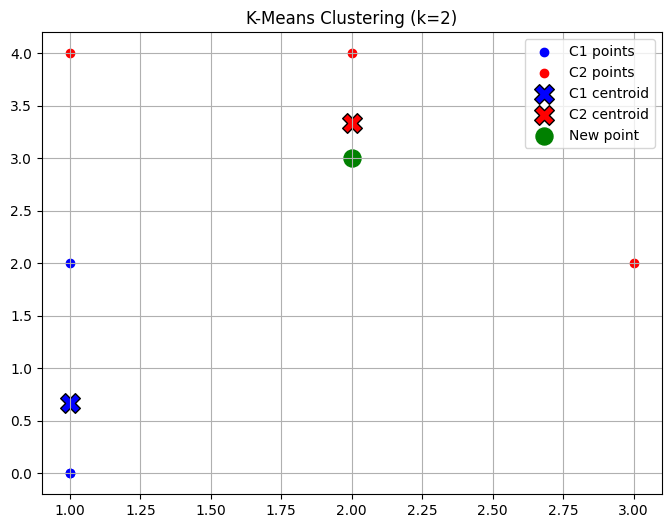

In [8]:
import numpy as np
import matplotlib.pyplot as plt
# Step 1: Define dataset
points = {
   'A': np.array([1, 2]),
   'B': np.array([1, 4]),
   'C': np.array([1, 0]),
   'D': np.array([3, 2]),
   'E': np.array([2, 4]),
   'F': np.array([1, 0])
}
# Convert to numpy array for easier handling
data = np.array(list(points.values()))
# Step 2: Initialize centroids (pick A and D)
centroids = {
   'C1': points['A'],
   'C2': points['D']
}
def euclidean(p1, p2):
   return np.sqrt(np.sum((p1 - p2)**2))
# Function to assign points to closest centroid
def assign_clusters(data, centroids):
   clusters = {'C1': [], 'C2': []}
   for point in data:
       d1 = euclidean(point, centroids['C1'])
       d2 = euclidean(point, centroids['C2'])
       if d1 < d2:
           clusters['C1'].append(point)
       else:
           clusters['C2'].append(point)
   return clusters
# Function to update centroids
def update_centroids(clusters):
   new_centroids = {}
   for key in clusters:
       new_centroids[key] = np.mean(clusters[key], axis=0)
   return new_centroids
# Run K-Means until convergence
tolerance = 1e-4
for i in range(10):  # max 10 iterations
   clusters = assign_clusters(data, centroids)
   new_centroids = update_centroids(clusters)
   # Check convergence
   diff = sum(euclidean(centroids[key], new_centroids[key]) for key in centroids)
   centroids = new_centroids
   if diff < tolerance:
       break
# Final clusters and centroids
print("Final centroids:")
for k, v in centroids.items():
   print(f"{k}: {v}")
# Predict a new point
new_point = np.array([2, 3])
d1 = euclidean(new_point, centroids['C1'])
d2 = euclidean(new_point, centroids['C2'])
assigned_cluster = 'C1' if d1 < d2 else 'C2'
print(f"\nNew point {new_point} assigned to: {assigned_cluster}")
# Plotting
colors = {'C1': 'blue', 'C2': 'red'}
plt.figure(figsize=(8, 6))
for cluster in clusters:
   cluster_points = np.array(clusters[cluster])
   plt.scatter(cluster_points[:, 0], cluster_points[:, 1],
               c=colors[cluster], label=f"{cluster} points")
# Plot centroids
for key, centroid in centroids.items():
   plt.scatter(*centroid, c=colors[key], marker='X', s=200, edgecolor='black', label=f"{key} centroid")
# Plot new point
plt.scatter(*new_point, c='green', marker='o', s=150, label='New point')
plt.title('K-Means Clustering (k=2)')
plt.legend()
plt.grid(True)
plt.show()